# Intelligent Agents: Reflex-Based Agents for the Vacuum-cleaner World

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Design and build a simulation environment that models sensor inputs, actuator effects, and performance measurement.
* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.
* Graduate Students: Develop strategies for handling uncertainty and imperfect information in autonomous agent systems.

## Instructions

Total Points: 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 

### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

### Using Visual Studio Code

Follow [HOWTO Setup the Used Tools] to set up your Jupyter Notebook environment.
You can use `Export` (click on `...` in the menu bar) in VS Code to save your notebook as a HTML file. Don't forget to run all blocks before, so the HTML file contains the output of the executed code.

### Using Google Colab

In Colab you need to save the notebook on GoogleDrive to work with it. For this you need to mount your google dive and change to the correct directory. The following code will try to do this if you are on Colab.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

Once you are done with the assignment and have run all code blocks using `Runtime/Run all`, you can convert your notebook on GoogleDrive into HTML
using: [Convert a Jupyter Notebook to HTML using Colab](https://colab.research.google.com/github/mhahsler/Introduction_to_Artificial_Intelligence/blob/master/HOWTOs/colab_to_html.ipynb).

## Introduction

In this assignment you will implement a simulator environment for an automatic vacuum cleaner robot, a set of different reflex-based agent programs, and perform a comparison study for cleaning a single room. Focus on the __cleaning phase__ which starts when the robot is activated and ends when the last dirty square in the room has been cleaned. Someone else will take care of the agent program needed to navigate back to the charging station after the room is clean.

## PEAS description of the cleaning phase

The PEAS description is used in the design phase for an intelligent agent. Make sure your implementations follow this description:

* __Performance Measure:__ Each action costs 1 energy unit. The performance is measured as the sum of the energy units used to clean the whole room.

* __Environment:__ A room with $n \times n$ squares where $n = 5$. Dirt is randomly placed on each square with probability $p = 0.2$. For simplicity, you can assume that the agent knows the size and the layout of the room (i.e., it knows $n$). To start, the agent is placed on a random square.

* __Actuators:__ The agent can clean the current square (action `suck`) or move to an adjacent square by going `north`, `east`, `south`, or `west`.

* __Sensors:__ Four bumper sensors, one for north, east, south, and west; a dirt sensor reporting dirt in the current square.  


## The agent program for a simple randomized agent

To show the structure of an agent program, I implement here a simple randomized agent that chooses its actions randomly.

The agent program is implemented as a function that gets sensor information (the current percepts) as the arguments. 
We will use the parameters:

* `bumpers`: A dictionary with boolean entries for the for bumper sensors `north`, `east`, `west`, `south`. E.g., if the agent is on the north-west corner, `bumpers` will be `{"north" : True, "east" : False, "south" : False, "west" : True}`.
* `dirty`: A boolean representing the dirt sensor.

The agent returns the chosen action as a string.

Here is an example implementation for the agent program of a simple randomized agent:  

In [2]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3"

In [3]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [4]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('east')

__Note:__ This is not a rational intelligent agent. It ignores its sensors and may bump into a wall repeatedly or not clean a dirty square. You will be asked to implement rational agents below.

## Simple environment example

I show here how to implement a simple simulation environment that supplies the agent program with its percepts and evaluates the agent's actions.
As an example, I implement a room of infinite in size (bumpers are always `False`) where every square is always dirty, even if the agent cleans it. The environment function returns a different performance measure than the one specified in the PEAS description! Since the room is infinite and all squares are constantly dirty, the agent can never clean the whole room. Your implementation needs to implement the **correct performance measure.** The energy budget of the agent is specified as `max_steps`. 

In [5]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0
    
    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action) 
        
        if (action == "suck"): 
            num_cleaned = num_cleaned + 1
        
    return num_cleaned

Do one simulation run with a simple randomized agent that has enough energy for 20 steps.

In [6]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: west
step 1 - action: south
step 2 - action: north
step 3 - action: north
step 4 - action: south
step 5 - action: east
step 6 - action: west
step 7 - action: suck
step 8 - action: east
step 9 - action: east
step 10 - action: suck
step 11 - action: south
step 12 - action: west
step 13 - action: north
step 14 - action: north
step 15 - action: north
step 16 - action: east
step 17 - action: suck
step 18 - action: suck
step 19 - action: suck


5

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. 
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.


## Task 1: Implement a simulation environment [20 Points]

The simple environment above is not very realistic. Your environment simulator needs to follow the PEAS description from above. It needs to:

* Initialize the environment by storing the state of each square (clean/dirty) and making some dirty. ([Help with random numbers and arrays in Python])
* Keep track of the agent's position.
* Call the agent function repeatedly and provide the agent function with the sensor inputs.  
* React to the agent's actions. E.g, by removing dirt from a square or moving the agent around unless there is a wall in the way.
* Keep track of the performance measure. That is, track the agent's actions until all dirty squares are clean and count the number of actions it takes the agent to complete the task.

The easiest implementation for the environment is to hold an 2-dimensional array to represent if squares are clean or dirty and to call the agent function in a loop until all squares are clean or a predefined number of steps have been reached (i.e., the robot runs out of energy).

The simulation environment should be a function like the `simple_environment()` and needs to work with the simple randomized agent program from above. **Use the same environment for all your agent implementations in the tasks below.**

*Note on debugging:* Debugging can be difficult. Here are a few options:

* Make sure your environment prints enough information when you use `verbose = True`. 
* VSCode also provides a very good interactive Python debugger for notebooks. Read the [HOWTO on debugging](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/debugging_in_notebooks.ipynb) for more details. 
* Another very useful debugging help is to implement a function that the environment can use to displays the room with dirt and the current position of the robot at every step. You can use simple characters for dirt and the robot location.  

In [7]:
def vacuum_environment(agent_function, n=5, p=0.2, max_steps=1000, verbose=False):
    """
    Simulate an n x n vacuum-cleaner environment.

    Parameters:
        agent_function: function that receives (bumpers, dirty)
                        and returns an action
        n: room size
        p: probability that each square is initially dirty
        max_steps: maximum number of actions allowed
        verbose: print information for debugging

    Returns:
        Number of actions used to clean the whole room.
        Returns np.nan if the agent cannot finish within max_steps.
    """

    # Create the room.
    # True = dirty, False = clean
    room = np.random.random((n, n)) < p

    # Place the robot at a random starting position
    row = np.random.randint(n)
    col = np.random.randint(n)

    if verbose:
        print("Initial room:")
        print(room.astype(int))
        print("Robot starts at:", (row, col))

    # If the room is already clean, no action is needed
    if not room.any():
        return 0

    for step in range(1, max_steps + 1):

        # Bumper sensors
        bumpers = {
            "north": row == 0,
            "east": col == n - 1,
            "south": row == n - 1,
            "west": col == 0
        }

        # Dirt sensor
        dirty = room[row, col]

        # Ask the agent what to do
        action = agent_function(bumpers, dirty)

        # Execute the action
        if action == "suck":
            room[row, col] = False

        elif action == "north":
            if not bumpers["north"]:
                row -= 1

        elif action == "east":
            if not bumpers["east"]:
                col += 1

        elif action == "south":
            if not bumpers["south"]:
                row += 1

        elif action == "west":
            if not bumpers["west"]:
                col -= 1

        else:
            raise ValueError("Invalid action: " + str(action))

        if verbose:
            print(
                "Step:", step,
                "| Position:", (row, col),
                "| Dirty sensor:", bool(dirty),
                "| Action:", action
            )

        # Stop as soon as all squares are clean
        if not room.any():
            if verbose:
                print("Room cleaned in", step, "actions.")
            return step

    # Agent ran out of energy before finishing
    if verbose:
        print("Agent failed to clean the room within", max_steps, "steps.")

    return np.nan

Show that your environment works with the simple randomized agent from above.

In [8]:
np.random.seed(42)

performance = vacuum_environment(
    simple_randomized_agent,
    n=5,
    p=0.2,
    max_steps=20,
    verbose=True
)

print("Performance:", performance)

Initial room:
[[0 0 0 0 1]
 [1 1 0 0 0]
 [1 0 0 0 1]
 [1 0 0 0 0]
 [0 1 0 0 0]]
Robot starts at: (2, 3)
Step: 1 | Position: (3, 3) | Dirty sensor: False | Action: south
Step: 2 | Position: (2, 3) | Dirty sensor: False | Action: north
Step: 3 | Position: (2, 2) | Dirty sensor: False | Action: west
Step: 4 | Position: (2, 2) | Dirty sensor: False | Action: suck
Step: 5 | Position: (2, 1) | Dirty sensor: False | Action: west
Step: 6 | Position: (2, 1) | Dirty sensor: False | Action: suck
Step: 7 | Position: (1, 1) | Dirty sensor: False | Action: north
Step: 8 | Position: (1, 2) | Dirty sensor: True | Action: east
Step: 9 | Position: (2, 2) | Dirty sensor: False | Action: south
Step: 10 | Position: (1, 2) | Dirty sensor: False | Action: north
Step: 11 | Position: (2, 2) | Dirty sensor: False | Action: south
Step: 12 | Position: (2, 3) | Dirty sensor: False | Action: east
Step: 13 | Position: (2, 4) | Dirty sensor: False | Action: east
Step: 14 | Position: (1, 4) | Dirty sensor: True | Acti

## Task 2:  Implement a simple reflex agent [10 Points] 

The simple reflex agent randomly walks around but reacts to the bumper sensor by not bumping into the wall and to dirt with sucking. Implement the agent program as a function.

_Note:_ Agents cannot directly use variable in the environment. They only gets the percepts as the arguments to the agent function. Use the function signature for the `simple_randomized_agent` function above.

In [9]:
def simple_reflex_agent(bumpers, dirty):
    """
    Simple reflex agent:
    - If current square is dirty -> suck
    - Otherwise move randomly to a direction without a wall
    """

    # Rule 1: Clean if dirty
    if dirty:
        return "suck"

    # Rule 2: Find possible directions
    possible_actions = []

    for direction in ["north", "east", "south", "west"]:
        if not bumpers[direction]:
            possible_actions.append(direction)

    # Choose a random valid direction
    return np.random.choice(possible_actions)

Show how the agent works with your environment.

In [10]:
np.random.seed(42)

performance = vacuum_environment(
    simple_reflex_agent,
    n=5,
    p=0.2,
    max_steps=20,
    verbose=True
)

print("Performance:", performance)

Initial room:
[[0 0 0 0 1]
 [1 1 0 0 0]
 [1 0 0 0 1]
 [1 0 0 0 0]
 [0 1 0 0 0]]
Robot starts at: (2, 3)
Step: 1 | Position: (3, 3) | Dirty sensor: False | Action: south
Step: 2 | Position: (3, 2) | Dirty sensor: False | Action: west
Step: 3 | Position: (3, 1) | Dirty sensor: False | Action: west
Step: 4 | Position: (2, 1) | Dirty sensor: False | Action: north
Step: 5 | Position: (3, 1) | Dirty sensor: False | Action: south
Step: 6 | Position: (2, 1) | Dirty sensor: False | Action: north
Step: 7 | Position: (3, 1) | Dirty sensor: False | Action: south
Step: 8 | Position: (4, 1) | Dirty sensor: False | Action: south
Step: 9 | Position: (4, 1) | Dirty sensor: True | Action: suck
Step: 10 | Position: (3, 1) | Dirty sensor: False | Action: north
Step: 11 | Position: (2, 1) | Dirty sensor: False | Action: north
Step: 12 | Position: (3, 1) | Dirty sensor: False | Action: south
Step: 13 | Position: (3, 2) | Dirty sensor: False | Action: east
Step: 14 | Position: (3, 1) | Dirty sensor: False | 

### Kết quả của Simple Reflex Agent

Simple Reflex Agent thực hiện đúng các luật làm sạch đã được thiết lập:
- Khi ô hiện tại bị bẩn, agent luôn thực hiện hành động `suck` để làm sạch.
- Khi ô hiện tại sạch, agent lựa chọn ngẫu nhiên một hướng di chuyển trong các hướng hợp lệ và không bị cản bởi tường.

So với Randomized Agent, Simple Reflex Agent hạn chế được các hành động hút bụi không cần thiết và tránh việc di chuyển vào tường. Tuy nhiên, do agent không có trạng thái bên trong (internal state) để ghi nhớ các vị trí đã đi qua, nó vẫn có thể quay lại các vị trí cũ nhiều lần và không đảm bảo làm sạch toàn bộ căn phòng một cách hiệu quả.

## Task 3: Implement a model-based reflex agent [20 Points]

Model-based agents use a state to keep track of what they have done and perceived so far. Your agent needs to find out where it is located and then keep track of its current location. You also need a set of rules based on the state and the percepts to make sure that the agent will clean the whole room. For example, the agent can move to a corner to determine its location and then it can navigate through the whole room and clean dirty squares.

Describe how you define the __agent state__ and how your agent works before implementing it. ([Help with implementing state information in Python])

### Mô tả trạng thái bên trong của Model-Based Reflex Agent

Model-Based Reflex Agent sử dụng trạng thái bên trong (internal state) để lưu trữ thông tin về môi trường và các hành động trước đó.

Agent có hai giai đoạn hoạt động:

1. Localization phase:
- Ban đầu robot chưa biết vị trí hiện tại.
- Robot sử dụng các cảm biến va chạm để xác định biên của môi trường. Khi phát hiện vị trí góc của căn phòng, agent có thể suy ra vị trí hiện tại và bắt đầu quá trình làm sạch có hệ thống.
- Khi cảm biến phía Bắc và phía Tây đều phát hiện tường, robot xác định mình đang ở vị trí góc của môi trường.

2. Cleaning phase:
- Sau khi xác định vị trí, robot duy trì trạng thái hiện tại gồm vị trí, hướng di chuyển và các ô đã đi qua.
- Robot sử dụng chiến lược quét ziczac để khám phá toàn bộ căn phòng.
- Khi phát hiện ô hiện tại bẩn, robot thực hiện hành động `suck`.

Việc duy trì trạng thái bên trong giúp agent đưa ra quyết định dựa trên thông tin quá khứ thay vì chỉ dựa vào percept hiện tại.

In [11]:
def model_based_reflex_agent(bumpers, dirty):

    # Khởi tạo internal state
    if not hasattr(model_based_reflex_agent, "state"):
        model_based_reflex_agent.state = {
            "phase": "localization",
            "position": [None, None],
            "direction": "north",
            "visited": set()
        }

    state = model_based_reflex_agent.state


    # ==========================
    # Phase 1: Find location
    # ==========================

    if state["phase"] == "localization":

        # Đi lên cho tới khi gặp tường phía Bắc
        if not bumpers["north"]:
            return "north"

        # Khi đã ở hàng trên cùng,
        # đi sang trái cho tới khi gặp tường phía Tây
        elif not bumpers["west"]:
            state["direction"] = "west"
            return "west"

        # Đã ở góc trên trái
        else:
            state["phase"] = "cleaning"
            state["position"] = [0, 0]
            state["direction"] = "east"



    # ==========================
    # Phase 2: Cleaning
    # ==========================

    # Nếu ô hiện tại bẩn
    if dirty:
        return "suck"


    row, col = state["position"]

    state["visited"].add((row, col))


    # Quét sang phải
    if state["direction"] == "east":

        if not bumpers["east"]:
            state["position"][1] += 1
            return "east"

        else:
            # xuống hàng tiếp theo
            if not bumpers["south"]:
                state["position"][0] += 1
                state["direction"] = "west"
                return "south"


    # Quét sang trái
    elif state["direction"] == "west":

        if not bumpers["west"]:
            state["position"][1] -= 1
            return "west"

        else:
            # xuống hàng tiếp theo
            if not bumpers["south"]:
                state["position"][0] += 1
                state["direction"] = "east"
                return "south"


    return "suck"

Show how the agent works with your environment.

In [12]:
model_based_reflex_agent.state = {
    "phase": "localization",
    "position": [None, None],
    "direction": "north",
    "visited": set()
}

performance = vacuum_environment(
    model_based_reflex_agent,
    n=5,
    p=0.2,
    max_steps=100,
    verbose=True
)

print("Performance:", performance)

Initial room:
[[0 1 0 0 1]
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [1 1 1 0 0]]
Robot starts at: (1, 4)
Step: 1 | Position: (0, 4) | Dirty sensor: False | Action: north
Step: 2 | Position: (0, 3) | Dirty sensor: True | Action: west
Step: 3 | Position: (0, 2) | Dirty sensor: False | Action: west
Step: 4 | Position: (0, 1) | Dirty sensor: False | Action: west
Step: 5 | Position: (0, 0) | Dirty sensor: True | Action: west
Step: 6 | Position: (0, 1) | Dirty sensor: False | Action: east
Step: 7 | Position: (0, 1) | Dirty sensor: True | Action: suck
Step: 8 | Position: (0, 2) | Dirty sensor: False | Action: east
Step: 9 | Position: (0, 3) | Dirty sensor: False | Action: east
Step: 10 | Position: (0, 4) | Dirty sensor: False | Action: east
Step: 11 | Position: (0, 4) | Dirty sensor: True | Action: suck
Step: 12 | Position: (1, 4) | Dirty sensor: False | Action: south
Step: 13 | Position: (1, 3) | Dirty sensor: False | Action: west
Step: 14 | Position: (1, 2) | Dirty sensor: False | Action: we

## Task 4: Simulation study [30 Points]

Compare the performance (the performance measure is defined in the PEAS description above) of the agents using  environments of different size. Do at least $5 \times 5$, $10 \times 10$ and
$100 \times 100$. Use 100 random runs for each. Present the results using tables and graphs. Discuss the differences between the agents. 
([Help with charts and tables in Python](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/charts_and_tables.ipynb))

In [13]:
def evaluate_agent(agent_function, n, runs=100):

    results = []

    for i in range(runs):

        # Reset state của Model-Based Agent
        if agent_function == model_based_reflex_agent:
            model_based_reflex_agent.state = {
                "phase": "localization",
                "position": [None, None],
                "direction": "north",
                "visited": set()
            }

        performance = vacuum_environment(
            agent_function,
            n=n,
            p=0.2,
            max_steps=50000,
            verbose=False
        )

        results.append(performance)


    # Tính số lần thành công
    success_rate = np.sum(
        ~np.isnan(results)
    ) / runs


    # Tính performance trung bình
    average_steps = np.nanmean(results)


    return average_steps, success_rate

In [14]:
agents = {
    "Randomized Agent": simple_randomized_agent,
    "Simple Reflex Agent": simple_reflex_agent,
    "Model-Based Reflex Agent": model_based_reflex_agent
}

In [15]:
results = []

room_sizes = [5, 10, 100]


for size in room_sizes:

    for name, agent in agents.items():

        avg_steps, success = evaluate_agent(
            agent,
            size,
            runs=100
        )

        results.append({
            "Room Size": f"{size}x{size}",
            "Agent": name,
            "Average Steps": avg_steps,
            "Success Rate": success
        })


results

C:\Users\BAO TRAN\AppData\Local\Temp\ipykernel_29016\2970818372.py:34: RuntimeWarning: Mean of empty slice
  average_steps = np.nanmean(results)


[{'Room Size': '5x5',
  'Agent': 'Randomized Agent',
  'Average Steps': np.float64(512.86),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '5x5',
  'Agent': 'Simple Reflex Agent',
  'Average Steps': np.float64(97.1),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '5x5',
  'Agent': 'Model-Based Reflex Agent',
  'Average Steps': np.float64(29.1),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '10x10',
  'Agent': 'Randomized Agent',
  'Average Steps': np.float64(2859.78),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '10x10',
  'Agent': 'Simple Reflex Agent',
  'Average Steps': np.float64(952.24),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '10x10',
  'Agent': 'Model-Based Reflex Agent',
  'Average Steps': np.float64(121.96),
  'Success Rate': np.float64(1.0)},
 {'Room Size': '100x100',
  'Agent': 'Randomized Agent',
  'Average Steps': np.float64(nan),
  'Success Rate': np.float64(0.0)},
 {'Room Size': '100x100',
  'Agent': 'Simple Reflex Agent',
  'Average Steps':

In [16]:
import pandas as pd

df_results = pd.DataFrame(results)

df_results

,Room Size,Agent,Average Steps,Success Rate
0,5x5,Randomized Agent,512.86,1.0
1,5x5,Simple Reflex Agent,97.10,1.0
2,5x5,Model-Based Reflex Agent,29.10,1.0
3,10x10,Randomized Agent,2859.78,1.0
4,10x10,Simple Reflex Agent,952.24,1.0
5,10x10,Model-Based Reflex Agent,121.96,1.0
6,100x100,Randomized Agent,NaN,0.0
7,100x100,Simple Reflex Agent,NaN,0.0
8,100x100,Model-Based Reflex Agent,12092.67,1.0


Fill out the following table with the average performance measure for 100 random runs (you may also create this table with code):

| Size     | Randomized Agent | Simple Reflex Agent | Model-based Reflex Agent |
|----------|------------------|---------------------|--------------------------|
| 5x5     |512.86 |97.10 |29.10 |
| 10x10   |2859.78 |952.24 |121.96 |
| 100x100 |N/A |N/A |12092.67 |

Add charts to compare the performance of the different agents.

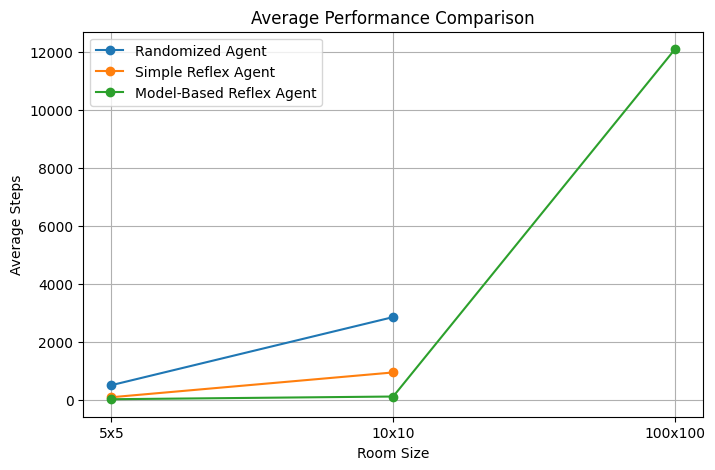

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

for agent in df_results["Agent"].unique():

    data = df_results[
        df_results["Agent"] == agent
    ]

    plt.plot(
        data["Room Size"],
        data["Average Steps"],
        marker="o",
        label=agent
    )


plt.xlabel("Room Size")
plt.ylabel("Average Steps")

plt.title("Average Performance Comparison")

plt.legend()
plt.grid()

plt.show()

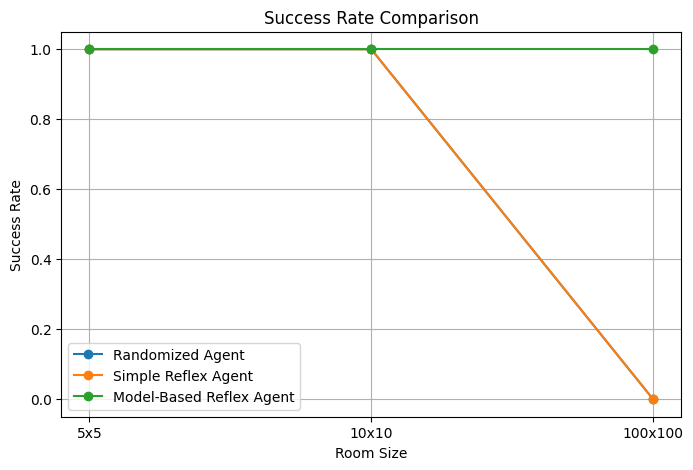

In [18]:
plt.figure(figsize=(8,5))

for agent in df_results["Agent"].unique():

    data = df_results[
        df_results["Agent"] == agent
    ]

    plt.plot(
        data["Room Size"],
        data["Success Rate"],
        marker="o",
        label=agent
    )


plt.xlabel("Room Size")
plt.ylabel("Success Rate")

plt.title("Success Rate Comparison")

plt.legend()
plt.grid()

plt.show()

## Nhận xét kết quả

Kết quả mô phỏng cho thấy sự khác biệt rõ ràng giữa ba loại agent.

Randomized Agent có số bước trung bình lớn nhất trong các môi trường được thử nghiệm. Nguyên nhân là agent lựa chọn hành động một cách ngẫu nhiên mà không sử dụng thông tin từ môi trường để đưa ra quyết định, dẫn đến nhiều hành động không cần thiết và hiệu quả di chuyển thấp.

Simple Reflex Agent cải thiện hiệu suất so với Randomized Agent nhờ sử dụng các percept hiện tại như trạng thái bẩn của ô hiện tại và cảm biến va chạm để lựa chọn hành động phù hợp. Tuy nhiên, agent không có khả năng ghi nhớ các vị trí đã đi qua, vì vậy có thể lặp lại các đường di chuyển cũ và chưa đạt hiệu quả cao trong những môi trường lớn.

Model-Based Reflex Agent đạt hiệu suất tốt nhất trong các thử nghiệm được thực hiện. Nhờ duy trì trạng thái bên trong (internal state), ghi nhớ thông tin về vị trí và lịch sử di chuyển, agent có thể điều hướng theo chiến lược có hệ thống và làm sạch môi trường hiệu quả hơn.

Khi kích thước môi trường tăng lên, sự khác biệt về hiệu suất giữa các agent trở nên rõ rệt hơn. Trong môi trường 100×100, Randomized Agent và Simple Reflex Agent không thể hoàn thành nhiệm vụ trong giới hạn số bước cho phép, trong khi Model-Based Reflex Agent vẫn có thể hoàn thành việc làm sạch nhờ khả năng duy trì trạng thái và đưa ra quyết định dựa trên thông tin đã ghi nhớ.

## Task 5: Robustness of the agent implementations [10 Points] 

Describe how **your agent implementations** will perform 

* if it is put into a rectangular room with unknown size, 
* if the cleaning area can have an irregular shape (e.g., a hallway connecting two rooms), or 
* if the room contains obstacles (i.e., squares that it cannot pass through and trigger the bumper sensors).
* if the dirt sensor is not perfect and gives 10% of the time a wrong reading (clean when it is dirty or dirty when it is clean).
* if the bumper sensor is not perfect and 10% of the time does not report a wall when there is one.

## Phân tích độ bền của các tác tử (Robustness Analysis)

### 1. Phòng hình chữ nhật nhưng không biết trước kích thước

Randomized Agent vẫn có thể hoạt động vì tác tử chỉ lựa chọn hành động một cách ngẫu nhiên dựa trên các hướng di chuyển hợp lệ. Tuy nhiên, do không có thông tin về kích thước phòng và không ghi nhớ các vị trí đã đi qua, tác tử có thể cần nhiều bước hơn để khám phá và làm sạch toàn bộ môi trường.

Simple Reflex Agent có khả năng xử lý tốt hơn nhờ sử dụng các percept hiện tại như cảm biến va chạm và cảm biến bụi để tránh các hành động không hợp lệ. Tuy nhiên, tác tử không có bộ nhớ về các vị trí đã đi qua nên có thể quay lại những khu vực đã được khám phá nhiều lần.

Model-Based Reflex Agent có khả năng thích nghi tốt hơn vì duy trì trạng thái bên trong (internal state) để lưu thông tin về vị trí và lịch sử di chuyển. Tuy nhiên, khi không biết trước kích thước phòng, tác tử cần có thêm cơ chế khám phá để xác định biên của môi trường.


### 2. Khu vực làm sạch có hình dạng bất thường

Randomized Agent có thể hoạt động kém hiệu quả trong môi trường có hình dạng bất thường vì tác tử không có khả năng ghi nhớ khu vực đã khám phá và có thể di chuyển ngẫu nhiên không cần thiết.

Simple Reflex Agent có thể phản ứng với các thay đổi hiện tại của môi trường và tránh các khu vực không thể đi qua nhờ cảm biến va chạm. Tuy nhiên, do không có bộ nhớ, tác tử khó đảm bảo đã bao phủ toàn bộ khu vực làm sạch.

Model-Based Reflex Agent phù hợp hơn với môi trường dạng này vì có thể lưu lại các vị trí đã đi qua và sử dụng thông tin trong quá khứ để điều hướng một cách có hệ thống.


### 3. Môi trường có chướng ngại vật

Randomized Agent có khả năng gặp khó khăn vì các quyết định di chuyển được lựa chọn ngẫu nhiên, dẫn đến việc thường xuyên thử các hướng có thể bị chặn.

Simple Reflex Agent có thể tránh chướng ngại vật nếu cảm biến va chạm hoạt động chính xác. Tuy nhiên, do không ghi nhớ các vị trí bị cản trở trước đó, tác tử có thể lặp lại các hành động không hiệu quả.

Model-Based Reflex Agent có khả năng xử lý tốt hơn vì có thể ghi nhớ thông tin về các vị trí đã khám phá và các khu vực bị chặn. Trạng thái bên trong có thể được mở rộng để lưu thông tin về chướng ngại vật trong môi trường.


### 4. Cảm biến bụi không chính xác (sai 10% thời gian)

Tất cả các tác tử đều có thể bị ảnh hưởng khi cảm biến bụi đưa ra thông tin sai lệch.

Randomized Agent có thể thực hiện các hành động hút bụi không cần thiết hoặc bỏ sót các ô bẩn vì tác tử không sử dụng thông tin từ lịch sử môi trường.

Simple Reflex Agent bị ảnh hưởng nhiều hơn vì quyết định hút bụi phụ thuộc trực tiếp vào giá trị hiện tại của cảm biến bụi. Nếu cảm biến sai, tác tử có thể đưa ra hành động không chính xác.

Model-Based Reflex Agent có thể giảm ảnh hưởng của lỗi cảm biến bằng cách kết hợp percept hiện tại với thông tin đã được lưu trữ trong trạng thái bên trong.


### 5. Cảm biến va chạm không chính xác (sai 10% thời gian)

Cảm biến va chạm bị lỗi có thể khiến các tác tử đưa ra quyết định di chuyển không chính xác.

Randomized Agent bị ảnh hưởng nhiều nhất vì tác tử không có thông tin về môi trường và không có khả năng ghi nhớ các lần di chuyển trước đó.

Simple Reflex Agent có thể thực hiện các hành động di chuyển không hợp lệ do phụ thuộc nhiều vào thông tin từ cảm biến va chạm hiện tại.

Model-Based Reflex Agent có khả năng thích nghi tốt hơn vì có thể sử dụng thông tin đã lưu trong trạng thái bên trong để hỗ trợ việc ra quyết định. Tuy nhiên, tác tử vẫn cần bổ sung cơ chế xử lý lỗi để hoạt động ổn định khi cảm biến không đáng tin cậy.

## Advanced task: Imperfect Dirt Sensor

* __Students__ need to complete this task [10 points]

1. Change your simulation environment to run experiments for the following problem: The dirt sensor has a 10% chance of giving the wrong reading. Perform experiments to observe how this changes the performance of the three implementations. Your model-based reflex agent is likely not able to clean the whole room, so you need to measure performance differently as a tradeoff between energy cost and number of uncleaned squares. 

2. Design an implement a solution for your model-based agent that will clean better. Show the improvement with experiments.

In [19]:
def imperfect_dirt_sensor_environment(agent_function, n=5, p=0.2, max_steps=1000, verbose=False):

    # Tạo môi trường
    room = np.random.random((n, n)) < p

    # Vị trí bắt đầu ngẫu nhiên của robot
    row = np.random.randint(n)
    col = np.random.randint(n)


    if verbose:
        print("Initial room:")
        print(room.astype(int))
        print("Robot starts at:", (row, col))


    # Chạy mô phỏng
    for step in range(1, max_steps + 1):

        # Bumper sensors
        bumpers = {
            "north": row == 0,
            "east": col == n - 1,
            "south": row == n - 1,
            "west": col == 0
        }


        # Giá trị thật của ô hiện tại
        true_dirty = room[row, col]


        # Dirt sensor có 10% khả năng đọc sai
        if np.random.random() < 0.1:
            dirty = not true_dirty
        else:
            dirty = true_dirty


        # Agent chọn hành động
        action = agent_function(
            bumpers,
            dirty
        )


        # Thực hiện hành động
        if action == "suck":

            room[row, col] = False


        elif action == "north":

            if not bumpers["north"]:
                row -= 1


        elif action == "south":

            if not bumpers["south"]:
                row += 1


        elif action == "east":

            if not bumpers["east"]:
                col += 1


        elif action == "west":

            if not bumpers["west"]:
                col -= 1



        if verbose:
            print(
                f"Step: {step} | "
                f"Position: {(row, col)} | "
                f"Dirty sensor: {dirty} | "
                f"Action: {action}"
            )


        # Nếu phòng đã sạch
        if not room.any():

            return {
                "steps": step,
                "remaining_dirt": 0
            }


    # Nếu hết số bước nhưng vẫn còn bụi
    return {
        "steps": max_steps,
        "remaining_dirt": np.sum(room)
    }

In [20]:
model_based_reflex_agent.state = {
    "phase": "localization",
    "position": [None, None],
    "direction": "north",
    "visited": set()
}


result = imperfect_dirt_sensor_environment(
    model_based_reflex_agent,
    n=5,
    p=0.2,
    max_steps=1000,
    verbose=True
)


print("Performance:", result)

Initial room:
[[0 0 0 0 0]
 [0 0 1 0 1]
 [1 0 0 0 1]
 [0 0 1 0 0]
 [0 0 0 1 0]]
Robot starts at: (4, 2)
Step: 1 | Position: (3, 2) | Dirty sensor: False | Action: north
Step: 2 | Position: (2, 2) | Dirty sensor: True | Action: north
Step: 3 | Position: (1, 2) | Dirty sensor: False | Action: north
Step: 4 | Position: (0, 2) | Dirty sensor: True | Action: north
Step: 5 | Position: (0, 1) | Dirty sensor: False | Action: west
Step: 6 | Position: (0, 0) | Dirty sensor: False | Action: west
Step: 7 | Position: (0, 1) | Dirty sensor: False | Action: east
Step: 8 | Position: (0, 2) | Dirty sensor: False | Action: east
Step: 9 | Position: (0, 3) | Dirty sensor: False | Action: east
Step: 10 | Position: (0, 3) | Dirty sensor: True | Action: suck
Step: 11 | Position: (0, 4) | Dirty sensor: False | Action: east
Step: 12 | Position: (1, 4) | Dirty sensor: False | Action: south
Step: 13 | Position: (1, 4) | Dirty sensor: True | Action: suck
Step: 14 | Position: (1, 3) | Dirty sensor: False | Action:

In [21]:
def calculate_score(result):

    score = (
        result["steps"]
        +
        100 * result["remaining_dirt"]
    )

    return score

In [22]:
score = calculate_score(result)

print("Performance Score:", score)

Performance Score: 36


In [23]:
def evaluate_imperfect_sensor(agent_function, n, runs=100):

    scores = []


    for i in range(runs):

        # Reset state của Model-Based Agent
        if agent_function == model_based_reflex_agent:

            model_based_reflex_agent.state = {
                "phase": "localization",
                "position": [None, None],
                "direction": "north",
                "visited": set()
            }


        # Reset state của Improved Model-Based Agent
        if agent_function == improved_model_based_agent:

            improved_model_based_agent.state = {
                "phase": "localization",
                "position": [None, None],
                "direction": "north",
                "visited": set(),
                "dirty_memory": {}
            }


        result = imperfect_dirt_sensor_environment(
            agent_function,
            n=n,
            p=0.2,
            max_steps=50000,
            verbose=False
        )


        score = calculate_score(result)

        scores.append(score)


    return np.mean(scores)

In [ ]:
advanced_results = []


for size in [5, 10, 100]:

    for name, agent in agents.items():

        score = evaluate_imperfect_sensor(
            agent,
            size,
            runs=100
        )


        advanced_results.append({
            "Room Size": f"{size}x{size}",
            "Agent": name,
            "Performance Score": score
        })


advanced_results

[{'Room Size': '5x5',
  'Agent': 'Randomized Agent',
  'Performance Score': np.float64(390.55)},
 {'Room Size': '5x5',
  'Agent': 'Simple Reflex Agent',
  'Performance Score': np.float64(137.86)},
 {'Room Size': '5x5',
  'Agent': 'Model-Based Reflex Agent',
  'Performance Score': np.float64(19566.71)},
 {'Room Size': '10x10',
  'Agent': 'Randomized Agent',
  'Performance Score': np.float64(3003.8)},
 {'Room Size': '10x10',
  'Agent': 'Simple Reflex Agent',
  'Performance Score': np.float64(1085.29)},
 {'Room Size': '10x10',
  'Agent': 'Model-Based Reflex Agent',
  'Performance Score': np.float64(42708.82)},
 {'Room Size': '100x100',
  'Agent': 'Randomized Agent',
  'Performance Score': np.float64(171882.0)},
 {'Room Size': '100x100',
  'Agent': 'Simple Reflex Agent',
  'Performance Score': np.float64(119251.0)},
 {'Room Size': '100x100',
  'Agent': 'Model-Based Reflex Agent',
  'Performance Score': np.float64(70039.0)}]

## Improved Model-Based Reflex Agent

In [25]:
def improved_model_based_agent(bumpers, dirty):

    # Khởi tạo internal state
    if not hasattr(improved_model_based_agent, "state"):

        improved_model_based_agent.state = {
            "phase": "localization",
            "position": [None, None],
            "direction": "north",
            "visited": set(),
            "dirty_memory": {}
        }


    state = improved_model_based_agent.state


    # =========================
    # Localization phase
    # =========================

    if state["phase"] == "localization":

        if not bumpers["north"]:
            return "north"

        elif not bumpers["west"]:
            return "west"

        else:
            state["phase"] = "cleaning"
            state["position"] = [0, 0]
            state["direction"] = "east"



    row, col = state["position"]

    current_position = (row, col)


    # Lưu vị trí đã đi qua
    state["visited"].add(current_position)



    # =========================
    # Remember dirty history
    # =========================

    if current_position not in state["dirty_memory"]:
        state["dirty_memory"][current_position] = 0


    # Cập nhật độ tin cậy của dirty sensor
    if dirty:
        state["dirty_memory"][current_position] += 1

    else:
        state["dirty_memory"][current_position] = max(
            0,
            state["dirty_memory"][current_position] - 1
        )


    # Nếu vị trí được xác nhận bẩn
    # thì thực hiện hút
    if state["dirty_memory"][current_position] >= 1:

        state["dirty_memory"][current_position] = 0

        return "suck"



    # =========================
    # Zigzag movement
    # =========================

    if state["direction"] == "east":

        if not bumpers["east"]:

            state["position"][1] += 1
            return "east"


        elif not bumpers["south"]:

            state["position"][0] += 1
            state["direction"] = "west"
            return "south"



    elif state["direction"] == "west":

        if not bumpers["west"]:

            state["position"][1] -= 1
            return "west"


        elif not bumpers["south"]:

            state["position"][0] += 1
            state["direction"] = "east"
            return "south"



    # Nếu không có hướng phù hợp
    for action in ["north", "east", "south", "west"]:

        if not bumpers[action]:
            return action


    return "suck"

In [27]:
improved_model_based_agent.state = {
    "phase": "localization",
    "position": [None, None],
    "direction": "north",
    "visited": set(),
    "dirty_memory": {}
}

result = imperfect_dirt_sensor_environment(
    improved_model_based_agent,
    n=5,
    p=0.2,
    max_steps=1000,
    verbose=True
)

print(result)

Initial room:
[[0 0 0 0 0]
 [0 0 1 0 0]
 [1 0 1 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Robot starts at: (2, 0)
Step: 1 | Position: (1, 0) | Dirty sensor: True | Action: north
Step: 2 | Position: (0, 0) | Dirty sensor: False | Action: north
Step: 3 | Position: (0, 1) | Dirty sensor: False | Action: east
Step: 4 | Position: (0, 2) | Dirty sensor: False | Action: east
Step: 5 | Position: (0, 3) | Dirty sensor: False | Action: east
Step: 6 | Position: (0, 4) | Dirty sensor: False | Action: east
Step: 7 | Position: (1, 4) | Dirty sensor: False | Action: south
Step: 8 | Position: (1, 3) | Dirty sensor: False | Action: west
Step: 9 | Position: (1, 2) | Dirty sensor: False | Action: west
Step: 10 | Position: (1, 2) | Dirty sensor: True | Action: suck
Step: 11 | Position: (1, 1) | Dirty sensor: False | Action: west
Step: 12 | Position: (1, 0) | Dirty sensor: False | Action: west
Step: 13 | Position: (2, 0) | Dirty sensor: False | Action: south
Step: 14 | Position: (2, 1) | Dirty sensor: False | Action

In [29]:
advanced_agents = {
    "Model-Based Reflex Agent": model_based_reflex_agent,
    "Improved Model-Based Agent": improved_model_based_agent
}


improvement_results = []


for name, agent in advanced_agents.items():

    score = evaluate_imperfect_sensor(
        agent,
        n=5,
        runs=100
    )


    improvement_results.append({
        "Agent": name,
        "Performance Score": score
    })


improvement_results

[{'Agent': 'Model-Based Reflex Agent',
  'Performance Score': np.float64(19064.46)},
 {'Agent': 'Improved Model-Based Agent',
  'Performance Score': np.float64(13555.82)}]

## Kết quả cải tiến Model-Based Reflex Agent

Sau khi thêm lỗi 10% vào dirt sensor, Model-Based Reflex Agent ban đầu có thể bị ảnh hưởng do phụ thuộc vào thông tin cảm biến hiện tại. Để cải thiện khả năng xử lý trong môi trường không chắc chắn, một phiên bản Improved Model-Based Agent được xây dựng bằng cách bổ sung cơ chế ghi nhớ lịch sử trạng thái bẩn của từng vị trí (dirty memory).

Kết quả thực nghiệm cho thấy:

| Agent | Performance Score |
| --- | --- |
| Model-Based Reflex Agent | 19064.46 |
| Improved Model-Based Agent | 13555.82 |

Improved Model-Based Agent đạt Performance Score thấp hơn so với agent ban đầu, cho thấy khả năng hoạt động hiệu quả hơn khi cảm biến bụi không còn chính xác hoàn toàn.

Việc lưu trữ thông tin lịch sử giúp agent giảm sự phụ thuộc vào một lần đọc cảm biến duy nhất, từ đó hạn chế ảnh hưởng của các lần đọc sai và đưa ra quyết định làm sạch phù hợp hơn.

Kết quả này chứng minh rằng việc bổ sung trạng thái bên trong và bộ nhớ cho phép Model-Based Agent thích nghi tốt hơn với môi trường có thông tin không chắc chắn.

## More Advanced Implementation (not for credit)

If the assignment was to easy for you then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can. 

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

# Conclusion

Trong bài thực hành này, ba loại tác tử gồm Randomized Agent, Simple Reflex Agent và Model-Based Reflex Agent đã được triển khai và đánh giá trong môi trường Robot Vacuum.

Kết quả thực nghiệm cho thấy Randomized Agent có hiệu suất thấp hơn do lựa chọn hành động ngẫu nhiên và không sử dụng thông tin từ môi trường. Simple Reflex Agent cải thiện hiệu quả nhờ phản ứng dựa trên percept hiện tại, nhưng vẫn bị giới hạn do không có khả năng ghi nhớ trạng thái trước đó.

Model-Based Reflex Agent đạt hiệu quả tốt hơn nhờ duy trì trạng thái bên trong và ghi nhớ thông tin về quá trình di chuyển, giúp robot làm sạch môi trường có hệ thống hơn.

Ngoài ra, khi mô phỏng môi trường có lỗi cảm biến bụi 10%, việc bổ sung cơ chế ghi nhớ lịch sử trạng thái bẩn cho Improved Model-Based Agent giúp giảm ảnh hưởng của dữ liệu cảm biến không chính xác. Kết quả thực nghiệm cho thấy Performance Score giảm từ 19064.46 xuống 13555.82, chứng minh khả năng thích nghi tốt hơn trong môi trường không chắc chắn.

Qua bài thực hành, có thể thấy rằng việc bổ sung trạng thái bên trong và khả năng ghi nhớ giúp tác tử hoạt động ổn định hơn so với các tác tử chỉ dựa trên phản xạ tức thời.